# 시나리오 상상
- 이미지 데이터를 저장하고 있음
- 고차원 데이터 => 저장비용이 증가 => 비즈니스 고정비 상승
- PCA 원리를 활용하면, 시간적으로 처리속도 증가하고, 저장비용도 감소함.
- 원본 이미지 저장 => 하드웨어 투자 하자!!
  + 하드웨어 투자를 하기에 앞서서, 이미지를 압축해서 저장하는 스킬이 필요함
  + 행렬 분해(SVD/PCA) 활용하면 이미지 저장 비용이 줄어든다!

[비즈니스 보고서] 선형대수학 기반 인프라 고정비 절감 분석
[1] 시각적/데이터 품질 (Data Quality)
    - 분산 보존율(정보량): 98.43% 유지 (화질 손상 거의 없음)

[2] 클라우드 메모리 효율 (Storage Cost)
    - 원본 필요 스토리지: 786,432 Bytes
    - SVD 압축 스토리지: 358,600 Bytes
    => 비즈니스 효과: 스토리지/RAM 과금액 54.4% 영구 절감!

[3] AI 모델 추론 속도 (Compute Cost)
    - 원본 평균 연산 속도: 58.10 ms
    - SVD 평균 연산 속도: 24.39 ms
    => 비즈니스 효과: GPU/CPU 연산 시간 2.4배 속도 향상!

[4] 통계적 신뢰도 검증 (Paired t-test)
    - p-value: 3.01e-20 (가설 입증 완료)
    - 효과크기: Cohen's d = 2.56 (압도적인 효율성 증명)


/tmp/ipykernel_4038/1199387642.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['Original\nMatrix Multi', 'SVD\nAssociative Multi'], fontsize=12)


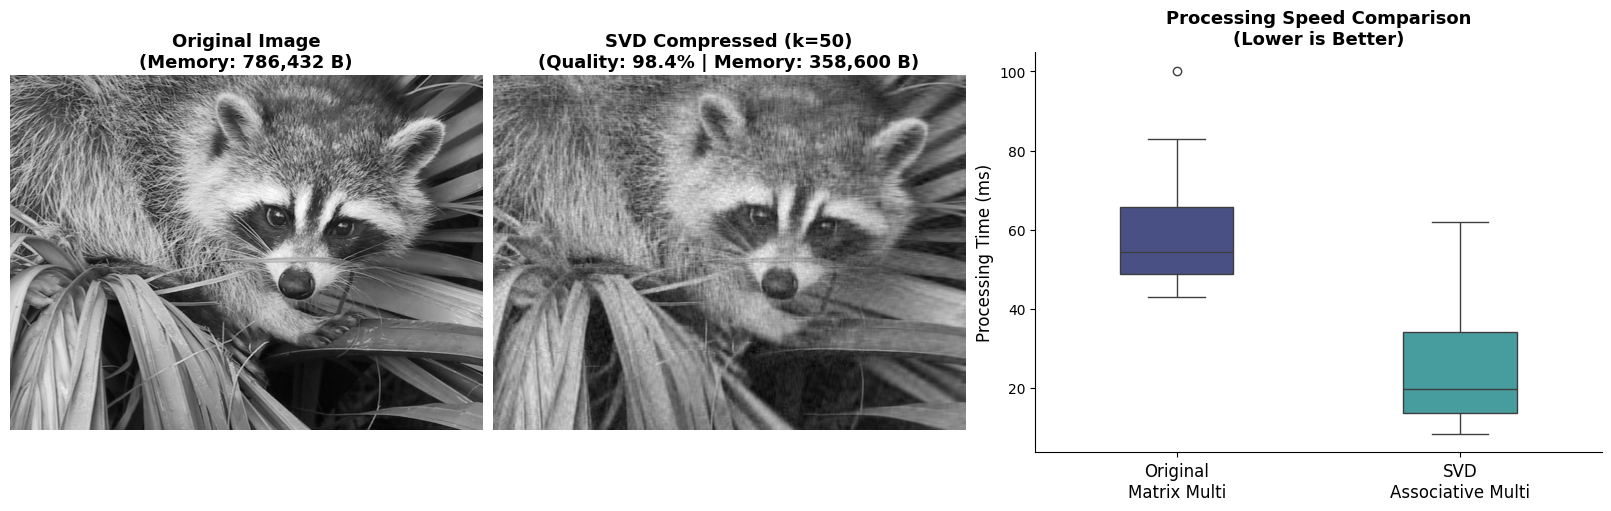

In [ ]:
import time
import numpy as np
import scipy.datasets
from scipy.linalg import svd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. 데이터 준비 및 SVD 수행
# ---------------------------------------------------------
img = scipy.datasets.face(gray=True) # 768 x 1024 고해상도 이미지
np.random.seed(42)
ai_weights = np.random.rand(img.shape[1], 500) # 가상의 AI 모델 (1024 x 500)

k_components = 50
U, S, Vt = svd(img, full_matrices=False)

U_k = U[:, :k_components]
S_k_diag = np.diag(S[:k_components])
Vt_k = Vt[:k_components, :]

# 압축된 행렬들을 다시 곱해서 눈으로 볼 수 있는 이미지로 복원
reconstructed_img = U_k @ S_k_diag @ Vt_k
variance_explained = (np.sum(S[:k_components]**2) / np.sum(S**2)) * 100

# 메모리 계산 (재무 지표용)
original_bytes = img.nbytes
compressed_bytes = U_k.nbytes + S[:k_components].nbytes + Vt_k.nbytes
memory_savings_pct = (1 - compressed_bytes / original_bytes) * 100

# ---------------------------------------------------------
# 2. 처리 시간 시뮬레이션 (통계용)
# ---------------------------------------------------------
n_iterations = 50
times_original, times_svd = [], []

for _ in range(n_iterations):
    # [A] 무거운 통짜 연산
    start = time.time()
    _ = img @ ai_weights
    times_original.append((time.time() - start) * 1000) # ms 단위 변환

    # [B] 가벼운 쪼개기 연산 (행렬 결합 법칙)
    start = time.time()
    _ = U_k @ (S_k_diag @ (Vt_k @ ai_weights))
    times_svd.append((time.time() - start) * 1000)

times_original, times_svd = np.array(times_original), np.array(times_svd)
differences = times_original - times_svd

# ---------------------------------------------------------
# 3. 통계 검정 분기
# ---------------------------------------------------------
_, shapiro_p = stats.shapiro(differences)

if shapiro_p >= 0.05:
    test_name = "Paired t-test"
    stat, p_val = stats.ttest_rel(times_original, times_svd, alternative='greater')
    pooled_std = np.sqrt((np.std(times_original, ddof=1)**2 + np.std(times_svd, ddof=1)**2) / 2)
    effect_size = np.mean(differences) / pooled_std
    effect_metric = f"Cohen's d = {effect_size:.2f}"
else:
    test_name = "Wilcoxon Signed-Rank Test"
    stat, p_val = stats.wilcoxon(differences, alternative='greater')
    z_stat = stats.norm.ppf(1 - p_val) if p_val < 0.5 else stats.norm.ppf(p_val)
    effect_size = abs(z_stat) / np.sqrt(n_iterations * 2)
    effect_metric = f"Effect size r = {effect_size:.2f}"

# ---------------------------------------------------------
# [A] Print: 재무/비즈니스 통계 리포트 출력
# ---------------------------------------------------------
print("=" * 65)
print("[비즈니스 보고서] 선형대수학 기반 인프라 고정비 절감 분석")
print("=" * 65)
print(f"[1] 시각적/데이터 품질 (Data Quality)")
print(f"    - 분산 보존율(정보량): {variance_explained:.2f}% 유지 (화질 손상 거의 없음)")

print(f"\n[2] 클라우드 메모리 효율 (Storage Cost)")
print(f"    - 원본 필요 스토리지: {original_bytes:,} Bytes")
print(f"    - SVD 압축 스토리지: {compressed_bytes:,} Bytes")
print(f"    => 비즈니스 효과: 스토리지/RAM 과금액 {memory_savings_pct:.1f}% 영구 절감!\n")

print(f"[3] AI 모델 추론 속도 (Compute Cost)")
print(f"    - 원본 평균 연산 속도: {np.mean(times_original):.2f} ms")
print(f"    - SVD 평균 연산 속도: {np.mean(times_svd):.2f} ms")
print(f"    => 비즈니스 효과: GPU/CPU 연산 시간 {(np.mean(times_original)/np.mean(times_svd)):.1f}배 속도 향상!\n")

print(f"[4] 통계적 신뢰도 검증 ({test_name})")
print(f"    - p-value: {p_val:.2e} (가설 입증 완료)")
print(f"    - 효과크기: {effect_metric} (압도적인 효율성 증명)")
print("=" * 65)

# ---------------------------------------------------------
# [B] Plot: FDV 원칙 기반 시각화 대시보드
# ---------------------------------------------------------
fig = plt.figure(figsize=(16, 5), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])

# 1) 원본 이미지
ax1 = fig.add_subplot(gs[0])
ax1.imshow(img, cmap='gray')
ax1.set_title(f"Original Image\n(Memory: {original_bytes:,} B)", fontsize=13, fontweight='bold')
ax1.axis('off')

# 2) SVD 압축 이미지
ax2 = fig.add_subplot(gs[1])
ax2.imshow(reconstructed_img, cmap='gray')
ax2.set_title(f"SVD Compressed (k={k_components})\n(Quality: {variance_explained:.1f}% | Memory: {compressed_bytes:,} B)",
              fontsize=13, fontweight='bold')
ax2.axis('off')

# 3) 속도 비교 박스플롯
ax3 = fig.add_subplot(gs[2])
sns.boxplot(data=[times_original, times_svd], palette="mako", ax=ax3, width=0.4)
ax3.set_xticklabels(['Original\nMatrix Multi', 'SVD\nAssociative Multi'], fontsize=12)
ax3.set_ylabel("Processing Time (ms)", fontsize=12)
ax3.set_title("Processing Speed Comparison\n(Lower is Better)", fontsize=13, fontweight='bold')
sns.despine(ax=ax3)

plt.show()

# 영화 추천 별점 예상
- 철수(액션), 영희(로맨스), 민수(다 좋아함)
- 유저 행렬 : 얼마나 좋아하는가?
- 영화 행렬 : 성분이 얼마나 들어 있는가?
- 유저 3명 (성향 행렬) => U
- 영화 3편 (성분 행렬) => V


In [ ]:
import numpy as np

users = ['Cheolsu (Action)', 'Younghee (Romance)', 'Minsu (Both)']

# 유저 성향 행렬
U = np.array([
    [5, 1], # 철수는 액션 5, 로맨스 1
    [1, 5], # 영희는 액션 1, 로맨스 5
    [4, 4]  # 민수는 액션 4, 로맨스 4
])

# 영화 성분 행렬
# 열 : 영화
# 행 : 액션 비중, 로맨스 비중 (1.0 만점 기준)
movies = ['Die Hard', 'Titanic', 'Terminator']
V_T = np.array([
    [1.0, 0.0, 0.9], # 액션 비중
    [0.0, 1.0, 0.1]  # 로맨스 성분 비중
])

# 선형대수 행렬 곱셈 연산
predicted_ratings = U @ V_T
predicted_ratings

array([[5. , 1. , 4.6],
       [1. , 5. , 1.4],
       [4. , 4. , 4. ]])

# 행렬의 정의
- 행렬(vector)은 수나 식을 직사각형 모양으로 배열
- 일반적으로 m개의 행과 n개의 열을 배열하여 m * n 행렬을 구성
- 같은 수의 행과 열을 가지면 정방행렬(square matrix)라고 부름
- 1 * n 행렬은 행벡터, n * 1 행렬은 열벡터라고 부름, 전치연산자(T)를 통해 행과 열을 서로 바꿀 수 있다.
- 크기가 같은 두 행렬은 같은 위치의 성분끼리 덧셈, 뺄셈, 스칼라 곱셈이 가능하다.


# $R^n$ 벡터공간
- 분석가가 '고객을 바라보는 렌즈의 개수(변수)'를 늘려가는 과정
- 고객의 나이, 구매액(2차원)
- 고객의 나이, 구매액, 방문횟수 (3차원)
- 분석을 하려면 더 많은 요인이 필요해 => $R^n$의 대수학적 확장
  + 추천 알고리즘 : 클릭 횟수, 체류 시간, 반품 이력... 등 수백개의 변수 추가
  + 100개의 변수 활용, 100차원($R^{100}$)

- 두 가지 필수 연산의 의미
  + 벡터의 덧셈 : 온라인 쇼핑 행동 벡터, 오프라인 매장 행동 벡터 => 고객의 통합 프로파일(Omni-Channel Profile) 완성
  + 스칼라 곱 : 마케팅 목표 설정, 현재 우수 고객 모든 활동량을 1.5배 곱을 한다.
    - 기존 고객 벡터의 방향성(취향)은 유지한 채, 규모를 스케일업(Scale-Up) 시뮬레이션

In [5]:
import numpy as np

# 벡터 (구매 횟수, 사이트 체류시간)
online_behavior = np.array([4, 2])
offline_behavior = np.array([1, 4])
scalar_growth = 1.5 # 가중치

# 벡터의 덧셈 : 두 행동 양식을 더해서, 옴니채널 통합 벡터 생성
integrated_v = online_behavior + offline_behavior
print(integrated_v)

# 스칼라 곱 : 통합된 고객 행동을 일정 비율로 스케일업
scaled_v = scalar_growth * integrated_v
print(scaled_v)

[5 6]
[7.5 9. ]


# 코사인 유사도
- 두 벡터의 내적을 각 벡터의 크기(Norm)의 곱으로 나눈 값이다.
- 콘텐츠 플랫폼 취향 매칭
  + 고객 A (헤비 유저) : 주말 내내 영화보는 사람 (액션 100시간, 로맨스 10시간, SF 50시간)
  + 고객 B (라이트 유저) : 한 달에 한 두편 (액션 10시간, 로맨스 1시간, SF 5시간)
- 두 고객의 절대적인 시청량(크기) 차이를 무시 => 장르별 비율(방향)이 같은지 확인

In [12]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

customer_A = np.array([100, 10, 50])
customer_B = np.array([10, 1, 5])

# 방식 1. Norm과 내적 직접 구현
dot_product = np.dot(customer_A, customer_B)
norm_A = np.linalg.norm(customer_A)
norm_B = np.linalg.norm(customer_B)

# 코사인 유사도 공식 적용
cos_sim_manual = dot_product / (norm_A * norm_B)
print(cos_sim_manual)


# 머신러닝 라이브러이 scikit-learn 방식
# 2차원 배열
A_2d = customer_A.reshape(1, -1)
B_2d = customer_B.reshape(1, -1)

cosine_similarity(A_2d, B_2d)[0][0]

1.0


np.float64(0.9999999999999999)